This notebook validates NFL player-tracking data and ensures physical correctness before modeling.

# Load Data Files

Loading Big Data Bowl 2023 Week 1 tracking data, plays metadata, and games metadata.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# Load the three data files
tracking = pd.read_csv('../data/raw/week1.csv')
plays = pd.read_csv('../data/raw/plays.csv')
games = pd.read_csv('../data/raw/games.csv')


## Games Data

The `games` dataframe contains metadata about each game, including teams playing, weather conditions, and game identifiers.


In [4]:
print("Games dataframe shape:", games.shape)
print("\nFirst 5 rows:")
display(games.head())
print("\nAll column names:")
print(games.columns.tolist())


Games dataframe shape: (122, 7)

First 5 rows:


,gameId,season,week,gameDate,gameTimeEastern,homeTeamAbbr,visitorTeamAbbr
0,2021090900,2021,1,09/09/2021,20:20:00,TB,DAL
1,2021091200,2021,1,09/12/2021,13:00:00,ATL,PHI
2,2021091201,2021,1,09/12/2021,13:00:00,BUF,PIT
3,2021091202,2021,1,09/12/2021,13:00:00,CAR,NYJ
4,2021091203,2021,1,09/12/2021,13:00:00,CIN,MIN



All column names:
['gameId', 'season', 'week', 'gameDate', 'gameTimeEastern', 'homeTeamAbbr', 'visitorTeamAbbr']


## Plays Data

The `plays` dataframe contains metadata about each individual play, including down, distance, play type, formation, personnel, and outcome information. Each play links to a specific game via `gameId`.


In [5]:
print("Plays dataframe shape:", plays.shape)
print("\nFirst 5 rows:")
display(plays.head())
print("\nAll column names:")
print(plays.columns.tolist())


Plays dataframe shape: (8557, 32)

First 5 rows:


,gameId,playId,playDescription,quarter,down,yardsToGo,possessionTeam,defensiveTeam,yardlineSide,yardlineNumber,...,foulNFLId3,absoluteYardlineNumber,offenseFormation,personnelO,defendersInBox,personnelD,dropBackType,pff_playAction,pff_passCoverage,pff_passCoverageType
0,2021090900,97,(13:33) (Shotgun) T.Brady pass incomplete deep...,1,3,2,TB,DAL,TB,33,...,NaN,43.0,SHOTGUN,"1 RB, 1 TE, 3 WR",6.0,"4 DL, 2 LB, 5 DB",TRADITIONAL,0,Cover-1,Man
1,2021090900,137,(13:18) (Shotgun) D.Prescott pass deep left to...,1,1,10,DAL,TB,DAL,2,...,NaN,108.0,EMPTY,"1 RB, 2 TE, 2 WR",6.0,"4 DL, 4 LB, 3 DB",TRADITIONAL,0,Cover-3,Zone
2,2021090900,187,(12:23) (Shotgun) D.Prescott pass short middle...,1,2,6,DAL,TB,DAL,34,...,NaN,76.0,SHOTGUN,"0 RB, 2 TE, 3 WR",6.0,"3 DL, 3 LB, 5 DB",TRADITIONAL,0,Cover-3,Zone
3,2021090900,282,(9:56) D.Prescott pass incomplete deep left to...,1,1,10,DAL,TB,TB,39,...,NaN,49.0,SINGLEBACK,"1 RB, 2 TE, 2 WR",6.0,"4 DL, 3 LB, 4 DB",TRADITIONAL,1,Cover-3,Zone
4,2021090900,349,(9:46) (Shotgun) D.Prescott pass incomplete sh...,1,3,15,DAL,TB,TB,44,...,NaN,54.0,SHOTGUN,"1 RB, 1 TE, 3 WR",7.0,"3 DL, 4 LB, 4 DB",TRADITIONAL,0,Cover-3,Zone



All column names:
['gameId', 'playId', 'playDescription', 'quarter', 'down', 'yardsToGo', 'possessionTeam', 'defensiveTeam', 'yardlineSide', 'yardlineNumber', 'gameClock', 'preSnapHomeScore', 'preSnapVisitorScore', 'passResult', 'penaltyYards', 'prePenaltyPlayResult', 'playResult', 'foulName1', 'foulNFLId1', 'foulName2', 'foulNFLId2', 'foulName3', 'foulNFLId3', 'absoluteYardlineNumber', 'offenseFormation', 'personnelO', 'defendersInBox', 'personnelD', 'dropBackType', 'pff_playAction', 'pff_passCoverage', 'pff_passCoverageType']


## Tracking Data

The `tracking` dataframe contains frame-by-frame position data for every player and the football during each play. Each row represents one player (or the ball) at one timestep (0.1 second intervals). This includes x,y coordinates, speed, acceleration, direction, and orientation.


## Filter to Standard Passing Plays

**Filtering Logic (Football Terms):**

- **Pass attempts only**: `passResult` in ['C', 'I', 'IN'] — completed passes, incompletions, or interceptions (excludes sacks and scrambles)
- **No spikes**: Exclude plays where the QB intentionally spikes the ball to stop the clock (description contains "spiked")
- **No trick plays**: Exclude laterals, reverses, or other non-standard pass attempts (description contains "lateral" or "FUMBLES")
- **Avoid desperation situations**: Exclude end-of-half/game prevent defense scenarios (`pff_passCoverage` != 'Prevent')
- **Standard dropback types**: Traditional dropbacks only (exclude scrambles, which are coded as passResult='R' anyway)

This ensures we analyze plays with normal quarterback dropbacks, standard route concepts, and typical coverage shells — ideal for inferring defensive responsibility.


In [6]:
# Filter to standard passing plays
standard_passes = plays[
    # Must be a pass attempt (complete, incomplete, or intercepted)
    (plays['passResult'].isin(['C', 'I', 'IN'])) &
    # Exclude spikes
    (~plays['playDescription'].str.contains('spiked', case=False, na=False)) &
    # Exclude trick plays with laterals or fumbles
    (~plays['playDescription'].str.contains('lateral|FUMBLES', case=False, na=False, regex=True)) &
    # Exclude prevent defense (desperation situations)
    (plays['pff_passCoverage'] != 'Prevent')
].copy()

# Select only requested columns
standard_passes_display = standard_passes[['gameId', 'playId', 'passResult', 'playDescription']]

print(f"Found {len(standard_passes_display)} standard passing plays")
print("\nFirst 20 standard passing plays:")
display(standard_passes_display.head(20))


Found 7457 standard passing plays

First 20 standard passing plays:


,gameId,playId,passResult,playDescription
0,2021090900,97,I,(13:33) (Shotgun) T.Brady pass incomplete deep...
1,2021090900,137,C,(13:18) (Shotgun) D.Prescott pass deep left to...
2,2021090900,187,C,(12:23) (Shotgun) D.Prescott pass short middle...
3,2021090900,282,I,(9:56) D.Prescott pass incomplete deep left to...
4,2021090900,349,I,(9:46) (Shotgun) D.Prescott pass incomplete sh...
5,2021090900,410,C,(8:53) (Shotgun) T.Brady pass short middle to ...
6,2021090900,434,I,"(8:24) (No Huddle, Shotgun) T.Brady pass incom..."
7,2021090900,456,C,(8:20) (Shotgun) T.Brady pass deep middle to R...
8,2021090900,480,C,"(7:53) (No Huddle, Shotgun) T.Brady pass deep ..."
9,2021090900,509,C,"(7:30) (No Huddle, Shotgun) T.Brady pass short..."


## Selected Play for Analysis

**gameId = 2021090900, playId = 1267**

Tom Brady short pass to Chris Godwin — 17-yard completion with tackle by A.Brown (Anthony Brown, Cowboys CB)


In [7]:
selected_game_id = 2021090900
selected_play_id = 1267

# Derive team abbreviations from plays metadata so nothing is hardcoded downstream
_play_meta = plays[
    (plays['gameId'] == selected_game_id) & (plays['playId'] == selected_play_id)
].iloc[0]
offense_team = _play_meta['possessionTeam']
defense_team = _play_meta['defensiveTeam']

print(f"Selected play: gameId={selected_game_id}, playId={selected_play_id}")
print(f"Offense: {offense_team}  |  Defense: {defense_team}")

Selected play: gameId=2021090900, playId=1267
Offense: TB  |  Defense: DAL


## Filter Tracking Data to Selected Play

Now we'll examine the frame-by-frame tracking data for this specific play.


In [8]:
# Filter tracking data to selected play
play_tracking = tracking[
    (tracking['gameId'] == selected_game_id) & 
    (tracking['playId'] == selected_play_id)
].copy()

print(f"Tracking data for gameId={selected_game_id}, playId={selected_play_id}")
print(f"Total rows: {len(play_tracking)}")
print("\nFirst 10 rows:")
display(play_tracking.head(10))


Tracking data for gameId=2021090900, playId=1267
Total rows: 966

First 10 rows:


,gameId,playId,nflId,frameId,time,jerseyNumber,team,playDirection,x,y,s,a,dis,o,dir,event
18331,2021090900,1267,25511.0,1,2021-09-10T01:14:50.700,12.0,TB,left,35.43,29.72,0.04,0.04,0.02,243.92,260.71,NaN
18332,2021090900,1267,25511.0,2,2021-09-10T01:14:50.800,12.0,TB,left,35.44,29.73,0.03,0.03,0.02,275.06,267.47,NaN
18333,2021090900,1267,25511.0,3,2021-09-10T01:14:50.900,12.0,TB,left,35.46,29.72,0.02,0.02,0.03,277.84,260.18,NaN
18334,2021090900,1267,25511.0,4,2021-09-10T01:14:51.000,12.0,TB,left,35.49,29.75,0.01,0.01,0.04,275.57,301.53,NaN
18335,2021090900,1267,25511.0,5,2021-09-10T01:14:51.100,12.0,TB,left,35.55,29.77,0.01,0.01,0.06,286.49,32.23,NaN
18336,2021090900,1267,25511.0,6,2021-09-10T01:14:51.200,12.0,TB,left,35.58,29.79,0.02,0.02,0.04,290.00,43.92,ball_snap
18337,2021090900,1267,25511.0,7,2021-09-10T01:14:51.300,12.0,TB,left,35.64,29.83,0.03,0.03,0.07,283.15,51.04,NaN
18338,2021090900,1267,25511.0,8,2021-09-10T01:14:51.400,12.0,TB,left,35.69,29.86,0.06,0.73,0.06,298.14,55.49,NaN
18339,2021090900,1267,25511.0,9,2021-09-10T01:14:51.500,12.0,TB,left,35.71,29.88,0.25,2.32,0.03,293.97,57.52,NaN
18340,2021090900,1267,25511.0,10,2021-09-10T01:14:51.600,12.0,TB,left,35.80,29.93,0.83,4.67,0.11,302.32,57.49,NaN


In [9]:
# Summarize frame structure
num_unique_frames = play_tracking['frameId'].nunique()
players_per_frame = play_tracking.groupby('frameId').size()

print("=" * 80)
print("FRAME STRUCTURE SUMMARY")
print("=" * 80)
print(f"Number of unique frames: {num_unique_frames}")
print(f"\nPlayer rows per frame:")
print(f"  Mean: {players_per_frame.mean():.1f}")
print(f"  Min:  {players_per_frame.min()}")
print(f"  Max:  {players_per_frame.max()}")
print(f"  Mode: {players_per_frame.mode()[0]}")
print("\nFrame distribution:")
print(players_per_frame.value_counts().sort_index())


FRAME STRUCTURE SUMMARY
Number of unique frames: 42

Player rows per frame:
  Mean: 23.0
  Min:  23
  Max:  23
  Mode: 23

Frame distribution:
23    42
Name: count, dtype: int64


## Column Definitions for Tracking Data

Each row in the tracking dataframe represents **one player or the football at one timestep** (0.1-second intervals).


In [10]:
# Display column information
print("All columns in tracking dataframe:")
print("=" * 80)
for col in play_tracking.columns:
    print(f"  {col}")
    
print("\n" + "=" * 80)
print("COLUMN EXPLANATIONS:")
print("=" * 80)

column_explanations = {
    'gameId': 'Unique identifier for the game',
    'playId': 'Unique identifier for the play within the game',
    'frameId': 'Sequential frame number (10 frames per second = 0.1s intervals)',
    'time': 'Timestamp of the frame (datetime format)',
    'jerseyNumber': 'Player jersey number (NaN for football)',
    'team': 'Team abbreviation (e.g., TB, DAL) or "football"',
    'playDirection': 'Direction of offensive play (left or right)',
    'x': 'Player x-coordinate (yards, parallel to sideline, 0-120 range)',
    'y': 'Player y-coordinate (yards, perpendicular to sideline, 0-53.3 range)',
    's': 'Speed in yards per second at this frame',
    'a': 'Acceleration in yards per second² at this frame',
    'dis': 'Distance traveled (yards) since previous frame',
    'o': 'Player orientation (degrees, 0-360) - direction body is facing',
    'dir': 'Direction of movement (degrees, 0-360) - direction player is moving',
    'event': 'Tagged play event at this frame (e.g., pass_forward, pass_arrived)',
    'nflId': 'Unique NFL player identifier (NaN for football)',
    'displayName': 'Player full name',
    'position': 'Player position (e.g., QB, CB, FS)',
    'height': 'Player height',
    'weight': 'Player weight'
}

for col, explanation in column_explanations.items():
    if col in play_tracking.columns:
        print(f"\n{col:15s}: {explanation}")


All columns in tracking dataframe:
  gameId
  playId
  nflId
  frameId
  time
  jerseyNumber
  team
  playDirection
  x
  y
  s
  a
  dis
  o
  dir
  event

COLUMN EXPLANATIONS:

gameId         : Unique identifier for the game

playId         : Unique identifier for the play within the game

frameId        : Sequential frame number (10 frames per second = 0.1s intervals)

time           : Timestamp of the frame (datetime format)

jerseyNumber   : Player jersey number (NaN for football)

team           : Team abbreviation (e.g., TB, DAL) or "football"

playDirection  : Direction of offensive play (left or right)

x              : Player x-coordinate (yards, parallel to sideline, 0-120 range)

y              : Player y-coordinate (yards, perpendicular to sideline, 0-53.3 range)

s              : Speed in yards per second at this frame

a              : Acceleration in yards per second² at this frame

dis            : Distance traveled (yards) since previous frame

o              : Player

## Static Spatial Plot — Single Frame Validation

Before animating or analyzing movement, we must visually validate:
- **Spatial correctness**: Are players in realistic field positions?
- **Field boundaries**: Do coordinates respect the 120×53.3 yard field?
- **Team separation**: Can we distinguish offense vs defense spatially?
- **Ball location**: Is the football in a logical position relative to players?
- **Formation structure**: Do players align in recognizable football formations?

This visual check ensures data quality before any temporal or spatial analysis.


In [11]:
# Select a frame to visualize (ball snap frame for formation view)
snap_frame = 6
frame_data = play_tracking[play_tracking['frameId'] == snap_frame].copy()

# Separate by team
offense = frame_data[frame_data['team'] == 'TB']
defense = frame_data[frame_data['team'] == 'DAL']
ball = frame_data[frame_data['team'] == 'football']

print(f"Frame {snap_frame} at snap:")
print(f"  Offense (TB): {len(offense)} players")
print(f"  Defense (DAL): {len(defense)} players")
print(f"  Ball: {len(ball)} entity")
print(f"\nPlay direction: {frame_data['playDirection'].iloc[0]}")


Frame 6 at snap:
  Offense (TB): 11 players
  Defense (DAL): 11 players
  Ball: 1 entity

Play direction: left


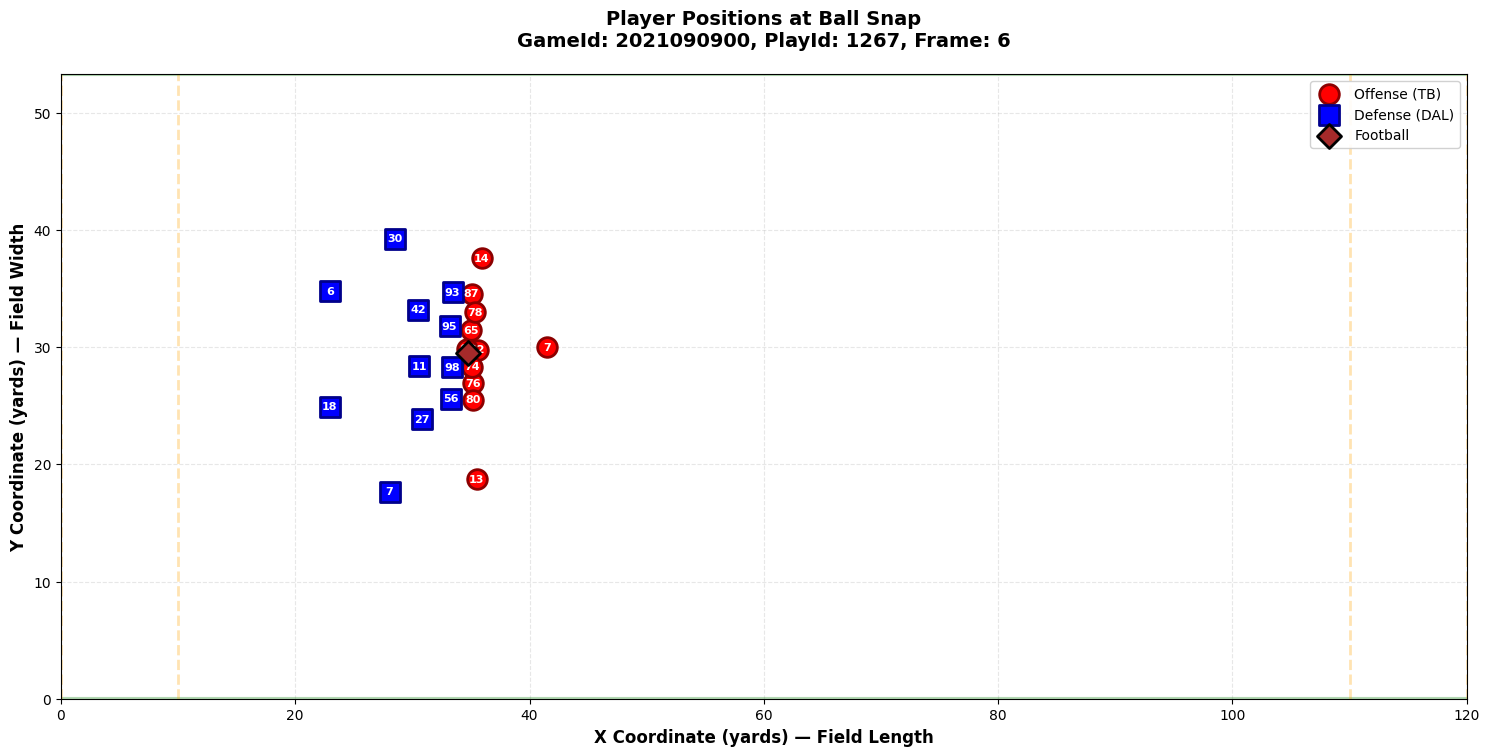


VISUAL VALIDATION CHECKLIST:
✓ All players within field boundaries (0-120 x, 0-53.3 y)?
✓ Offense and defense on opposite sides of the ball?
✓ Ball location makes sense (near line of scrimmage)?
✓ Formation recognizable (offensive line, receivers spread)?
✓ No overlapping players (distinct positions)?


In [12]:
# Create static plot
fig, ax = plt.subplots(figsize=(15, 8))

# Plot offense (Tampa Bay - red)
ax.scatter(offense['x'], offense['y'], 
           c='red', s=200, marker='o', 
           edgecolors='darkred', linewidth=2,
           label='Offense (TB)', zorder=3)

# Plot defense (Dallas - blue)
ax.scatter(defense['x'], defense['y'], 
           c='blue', s=200, marker='s', 
           edgecolors='darkblue', linewidth=2,
           label='Defense (DAL)', zorder=3)

# Plot ball (brown/orange)
ax.scatter(ball['x'], ball['y'], 
           c='brown', s=150, marker='D', 
           edgecolors='black', linewidth=2,
           label='Football', zorder=4)

# Add jersey numbers as labels
for _, player in offense.iterrows():
    if not np.isnan(player['jerseyNumber']):
        ax.text(player['x'], player['y'], str(int(player['jerseyNumber'])), 
                fontsize=8, ha='center', va='center', color='white', weight='bold')

for _, player in defense.iterrows():
    if not np.isnan(player['jerseyNumber']):
        ax.text(player['x'], player['y'], str(int(player['jerseyNumber'])), 
                fontsize=8, ha='center', va='center', color='white', weight='bold')

# Field dimensions and styling
ax.set_xlim(0, 120)
ax.set_ylim(0, 53.3)
ax.set_xlabel('X Coordinate (yards) — Field Length', fontsize=12, weight='bold')
ax.set_ylabel('Y Coordinate (yards) — Field Width', fontsize=12, weight='bold')
ax.set_title(f'Player Positions at Ball Snap\nGameId: {selected_game_id}, PlayId: {selected_play_id}, Frame: {snap_frame}', 
             fontsize=14, weight='bold', pad=20)

# Add grid for reference
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_aspect('equal', adjustable='box')

# Add legend
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)

# Add field markings context
ax.axhline(y=0, color='green', linewidth=3, alpha=0.3, label='Sideline')
ax.axhline(y=53.3, color='green', linewidth=3, alpha=0.3)
ax.axvline(x=0, color='orange', linewidth=2, alpha=0.3, linestyle='--', label='Endzone')
ax.axvline(x=10, color='orange', linewidth=2, alpha=0.3, linestyle='--')
ax.axvline(x=110, color='orange', linewidth=2, alpha=0.3, linestyle='--')
ax.axvline(x=120, color='orange', linewidth=2, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("VISUAL VALIDATION CHECKLIST:")
print("="*80)
print("✓ All players within field boundaries (0-120 x, 0-53.3 y)?")
print("✓ Offense and defense on opposite sides of the ball?")
print("✓ Ball location makes sense (near line of scrimmage)?")
print("✓ Formation recognizable (offensive line, receivers spread)?")
print("✓ No overlapping players (distinct positions)?")
print("="*80)


## Play Direction Normalization

### Why Plays Go Left vs Right

In NFL tracking data, the **field coordinate system is absolute** (0-120 yards), not relative to offense:
- **X-axis**: 0 to 120 yards (endzone to endzone)
- **Y-axis**: 0 to 53.3 yards (sideline to sideline)

Each team defends one endzone for the entire half. When a team has possession:
- If driving toward the **left endzone** (X → 0), `playDirection = 'left'`
- If driving toward the **right endzone** (X → 120), `playDirection = 'right'`

**Why this matters**: Teams switch directions at halftime, and even within a half, possession changes mean different offenses attack different directions. Without normalization, spatial logic (e.g., "defender depth behind LOS") would require direction-specific code.

### Normalization Strategy

We'll transform all plays to move **left-to-right** (increasing X):
- **If `playDirection = 'left'`**: Flip the field → `x_new = 120 - x_old`, `y_new = 53.3 - y_old`
- **If `playDirection = 'right'`**: Keep as-is (already left-to-right)

This also requires flipping angles (`o` and `dir`) by reflecting them: `angle_new = (angle_old + 180) % 360`


In [13]:
# Show current play direction and sample frames BEFORE normalization
print("BEFORE NORMALIZATION:")
print("=" * 80)
print(f"Play direction: {play_tracking['playDirection'].iloc[0]}")
print(f"\nSample frames (6-8) showing original coordinates:")

sample_before = play_tracking[play_tracking['frameId'].isin([6, 7, 8])][
    ['frameId', 'team', 'jerseyNumber', 'x', 'y', 'o', 'dir']
].head(9)

display(sample_before)


BEFORE NORMALIZATION:
Play direction: left

Sample frames (6-8) showing original coordinates:


,frameId,team,jerseyNumber,x,y,o,dir
18336,6,TB,12.0,35.58,29.79,290.00,43.92
18337,7,TB,12.0,35.64,29.83,283.15,51.04
18338,8,TB,12.0,35.69,29.86,298.14,55.49
18378,6,TB,87.0,35.05,34.57,277.42,314.83
18379,7,TB,87.0,35.02,34.60,306.07,316.50
18380,8,TB,87.0,34.96,34.66,324.78,322.67
18420,6,TB,66.0,34.64,29.87,260.68,188.26
18421,7,TB,66.0,34.63,29.82,255.43,186.92
18422,8,TB,66.0,34.63,29.75,252.20,183.45


In [14]:
# Normalize coordinates to make all plays go left-to-right
def normalize_play_direction(df):
    """
    Normalize tracking data so offense always moves left-to-right (increasing X).
    
    For plays going left (playDirection='left'):
    - Flip X: x_new = 120 - x_old
    - Flip Y: y_new = 53.3 - y_old  
    - Flip angles: angle_new = (angle_old + 180) % 360
    
    For plays going right: no change needed (already left-to-right)
    """
    df_normalized = df.copy()
    
    # Identify plays going left (need flipping)
    going_left = df_normalized['playDirection'] == 'left'
    
    # Flip spatial coordinates
    df_normalized.loc[going_left, 'x'] = 120 - df_normalized.loc[going_left, 'x']
    df_normalized.loc[going_left, 'y'] = 53.3 - df_normalized.loc[going_left, 'y']
    
    # Flip orientation and direction angles
    df_normalized.loc[going_left, 'o'] = (df_normalized.loc[going_left, 'o'] + 180) % 360
    df_normalized.loc[going_left, 'dir'] = (df_normalized.loc[going_left, 'dir'] + 180) % 360
    
    # Update playDirection to 'right' for consistency
    df_normalized.loc[going_left, 'playDirection'] = 'right'
    
    return df_normalized

# Apply normalization
play_tracking_normalized = normalize_play_direction(play_tracking)

print("Normalization complete!")
print(f"Original play direction: {play_tracking['playDirection'].iloc[0]}")
print(f"Normalized play direction: {play_tracking_normalized['playDirection'].iloc[0]}")


Normalization complete!
Original play direction: left
Normalized play direction: right


In [15]:
# Show same frames AFTER normalization
print("\nAFTER NORMALIZATION:")
print("=" * 80)
print(f"Play direction: {play_tracking_normalized['playDirection'].iloc[0]}")
print(f"\nSample frames (6-8) showing normalized coordinates:")

sample_after = play_tracking_normalized[play_tracking_normalized['frameId'].isin([6, 7, 8])][
    ['frameId', 'team', 'jerseyNumber', 'x', 'y', 'o', 'dir']
].head(9)

display(sample_after)



AFTER NORMALIZATION:
Play direction: right

Sample frames (6-8) showing normalized coordinates:


,frameId,team,jerseyNumber,x,y,o,dir
18336,6,TB,12.0,84.42,23.51,110.00,223.92
18337,7,TB,12.0,84.36,23.47,103.15,231.04
18338,8,TB,12.0,84.31,23.44,118.14,235.49
18378,6,TB,87.0,84.95,18.73,97.42,134.83
18379,7,TB,87.0,84.98,18.70,126.07,136.50
18380,8,TB,87.0,85.04,18.64,144.78,142.67
18420,6,TB,66.0,85.36,23.43,80.68,8.26
18421,7,TB,66.0,85.37,23.48,75.43,6.92
18422,8,TB,66.0,85.37,23.55,72.20,3.45


In [16]:
# Verify transformation with side-by-side comparison
print("\n" + "=" * 80)
print("VERIFICATION: Coordinate Transformation")
print("=" * 80)

# Get the ball position at snap (frame 6) before and after
ball_before = play_tracking[(play_tracking['frameId'] == 6) & (play_tracking['team'] == 'football')]
ball_after = play_tracking_normalized[(play_tracking_normalized['frameId'] == 6) & (play_tracking_normalized['team'] == 'football')]

print("\nBall position at snap (Frame 6):")
print(f"  BEFORE: X = {ball_before['x'].iloc[0]:.2f}, Y = {ball_before['y'].iloc[0]:.2f}")
print(f"  AFTER:  X = {ball_after['x'].iloc[0]:.2f}, Y = {ball_after['y'].iloc[0]:.2f}")
print(f"  Transform check: 120 - {ball_before['x'].iloc[0]:.2f} = {120 - ball_before['x'].iloc[0]:.2f}")
print(f"  Transform check: 53.3 - {ball_before['y'].iloc[0]:.2f} = {53.3 - ball_before['y'].iloc[0]:.2f}")

# Check QB (jersey #12) movement direction
qb_frames = play_tracking_normalized[(play_tracking_normalized['jerseyNumber'] == 12.0) & 
                                     (play_tracking_normalized['frameId'].isin([6, 16, 37]))]
print("\nQB (Tom Brady #12) X-coordinate over time:")
for _, row in qb_frames.iterrows():
    event_label = f" ({row['event']})" if pd.notna(row['event']) else ""
    print(f"  Frame {int(row['frameId']):2d}: X = {row['x']:.2f}{event_label}")

print("\n✓ After normalization, X should INCREASE as play progresses (left-to-right)")
print("=" * 80)



VERIFICATION: Coordinate Transformation

Ball position at snap (Frame 6):
  BEFORE: X = 34.77, Y = 29.50
  AFTER:  X = 85.23, Y = 23.80
  Transform check: 120 - 34.77 = 85.23
  Transform check: 53.3 - 29.50 = 23.80

QB (Tom Brady #12) X-coordinate over time:
  Frame  6: X = 84.42 (ball_snap)
  Frame 16: X = 82.67 (play_action)
  Frame 37: X = 78.68 (pass_forward)

✓ After normalization, X should INCREASE as play progresses (left-to-right)


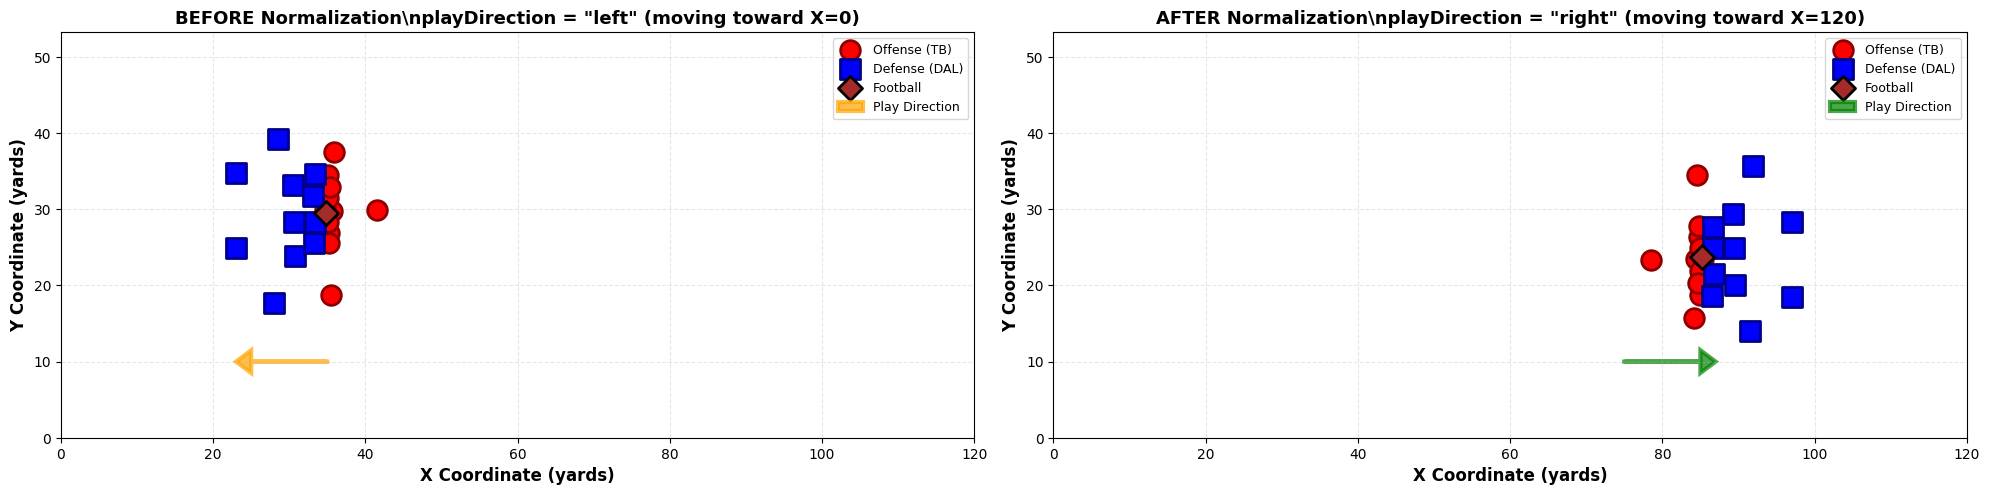

Visual comparison complete!
Notice: Field is flipped both horizontally (X) and vertically (Y) to maintain spatial relationships


In [17]:
# Visual comparison: Before and After normalization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

snap_frame = 6

# BEFORE normalization
frame_before = play_tracking[play_tracking['frameId'] == snap_frame]
offense_before = frame_before[frame_before['team'] == 'TB']
defense_before = frame_before[frame_before['team'] == 'DAL']
ball_before = frame_before[frame_before['team'] == 'football']

ax1.scatter(offense_before['x'], offense_before['y'], c='red', s=200, marker='o', 
           edgecolors='darkred', linewidth=2, label='Offense (TB)', zorder=3)
ax1.scatter(defense_before['x'], defense_before['y'], c='blue', s=200, marker='s',
           edgecolors='darkblue', linewidth=2, label='Defense (DAL)', zorder=3)
ax1.scatter(ball_before['x'], ball_before['y'], c='brown', s=150, marker='D',
           edgecolors='black', linewidth=2, label='Football', zorder=4)

# Add arrow showing play direction
ax1.arrow(35, 10, -10, 0, head_width=3, head_length=2, fc='orange', ec='orange', 
         linewidth=3, alpha=0.7, label='Play Direction')

ax1.set_xlim(0, 120)
ax1.set_ylim(0, 53.3)
ax1.set_xlabel('X Coordinate (yards)', fontsize=12, weight='bold')
ax1.set_ylabel('Y Coordinate (yards)', fontsize=12, weight='bold')
ax1.set_title(f'BEFORE Normalization\\nplayDirection = "left" (moving toward X=0)', 
             fontsize=13, weight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_aspect('equal', adjustable='box')
ax1.legend(loc='upper right', fontsize=9)

# AFTER normalization
frame_after = play_tracking_normalized[play_tracking_normalized['frameId'] == snap_frame]
offense_after = frame_after[frame_after['team'] == 'TB']
defense_after = frame_after[frame_after['team'] == 'DAL']
ball_after = frame_after[frame_after['team'] == 'football']

ax2.scatter(offense_after['x'], offense_after['y'], c='red', s=200, marker='o',
           edgecolors='darkred', linewidth=2, label='Offense (TB)', zorder=3)
ax2.scatter(defense_after['x'], defense_after['y'], c='blue', s=200, marker='s',
           edgecolors='darkblue', linewidth=2, label='Defense (DAL)', zorder=3)
ax2.scatter(ball_after['x'], ball_after['y'], c='brown', s=150, marker='D',
           edgecolors='black', linewidth=2, label='Football', zorder=4)

# Add arrow showing play direction
ax2.arrow(75, 10, 10, 0, head_width=3, head_length=2, fc='green', ec='green',
         linewidth=3, alpha=0.7, label='Play Direction')

ax2.set_xlim(0, 120)
ax2.set_ylim(0, 53.3)
ax2.set_xlabel('X Coordinate (yards)', fontsize=12, weight='bold')
ax2.set_ylabel('Y Coordinate (yards)', fontsize=12, weight='bold')
ax2.set_title(f'AFTER Normalization\\nplayDirection = "right" (moving toward X=120)',
             fontsize=13, weight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_aspect('equal', adjustable='box')
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

print("Visual comparison complete!")
print("Notice: Field is flipped both horizontally (X) and vertically (Y) to maintain spatial relationships")


In [18]:
# Update play_tracking to use normalized version for all future analysis
play_tracking = play_tracking_normalized.copy()

print("✓ Normalized tracking data is now the default for this play")
print(f"✓ Play direction: {play_tracking['playDirection'].iloc[0]}")
print(f"✓ All future spatial analysis will use left-to-right coordinate system")


✓ Normalized tracking data is now the default for this play
✓ Play direction: right
✓ All future spatial analysis will use left-to-right coordinate system


In [19]:
# Extract selected play details
selected_play = plays[(plays['gameId'] == selected_game_id) & (plays['playId'] == selected_play_id)]

print("Selected Play Details:")
print("=" * 80)
display(selected_play.T)  # Transpose to show all fields vertically


Selected Play Details:


,22
gameId,2021090900
playId,1267
playDescription,(11:13) T.Brady pass short right to C.Godwin t...
quarter,2
down,1
yardsToGo,10
possessionTeam,TB
defensiveTeam,DAL
yardlineSide,DAL
yardlineNumber,24


## Matplotlib Animation — Frame-by-Frame Player Movement

Now we'll create an animation that loops through the normalized tracking data, trimmed to the **meaningful play window** (snap → play end).

**Smart frame detection:**
- **Snap frame**: First frame tagged `ball_snap`
- **Pass release**: First frame tagged `pass_forward`
- **Approximate catch**: After pass release, the first frame where the ball is within 2 yards of a non-QB offensive player (works for completions; stays None for incompletions)
- **Play end**: Uses `tackle`, `out_of_bounds`, or `touchdown` events if present; otherwise adds a buffer after the catch to show run-after-catch

**Animation components:**
- **FuncAnimation**: matplotlib's animation engine that calls an update function for each frame
- **Dynamic team labels**: Offense/defense teams derived from `plays` metadata (not hardcoded)
- **Event annotations**: Title shows the current event tag (e.g., `ball_snap`, `pass_forward`) when one exists
- **Color coding**: Red (offense), Blue (defense), Brown (football)


Play event detection:
  Offense: TB  |  Defense: DAL
  Snap frame:       6
  Pass release:     37
  Approx catch:     38
  Animation end:    42
  Animating 37 frames (of 42 total)



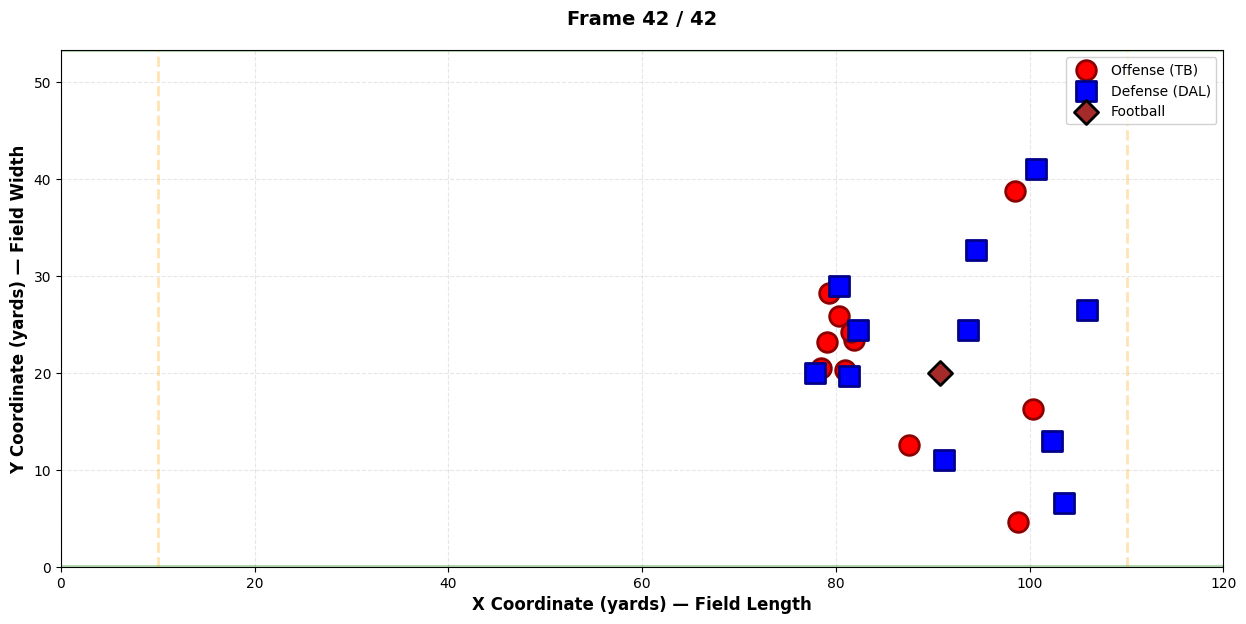

In [20]:
from matplotlib.animation import FuncAnimation
from IPython.display import display, HTML

# ---------------------------------------------------------------------------
# Detect key play events from tracking data
# ---------------------------------------------------------------------------
# Build a lookup: frameId -> event string (using any row that has an event)
frame_events = (
    play_tracking[play_tracking['event'].notna()]
    .groupby('frameId')['event']
    .first()
    .to_dict()
)

# offense_team and defense_team were derived from plays metadata in the setup cell
# (no hardcoded team abbreviations)

all_frames = sorted(play_tracking['frameId'].unique())

# Snap frame: first frame tagged 'ball_snap'
snap_frame = next((f for f in all_frames if frame_events.get(f) == 'ball_snap'), all_frames[0])

# Pass release frame: first frame tagged 'pass_forward'
pass_frame = next((f for f in all_frames if frame_events.get(f) == 'pass_forward'), None)

# ---------------------------------------------------------------------------
# Approximate the catch frame for completed passes
# ---------------------------------------------------------------------------
# After pass_forward, find the first frame where the ball is within 2 yards
# of a non-QB offensive player.  For incomplete passes this will stay None.
catch_frame = None
end_frame = all_frames[-1]

if pass_frame is not None:
    post_pass_frames = [f for f in all_frames if f > pass_frame]
    ball_rows = play_tracking[play_tracking['team'] == 'football'].set_index('frameId')

    # QB is typically the closest player at release; exclude them
    snap_data = play_tracking[play_tracking['frameId'] == snap_frame]
    ball_at_snap = snap_data[snap_data['team'] == 'football'][['x', 'y']].iloc[0]
    off_at_snap = snap_data[snap_data['team'] == offense_team]
    qb_dist = ((off_at_snap['x'] - ball_at_snap['x'])**2 +
               (off_at_snap['y'] - ball_at_snap['y'])**2) ** 0.5
    qb_nflId = off_at_snap.loc[qb_dist.idxmin(), 'nflId']

    for f in post_pass_frames:
        if f not in ball_rows.index:
            continue
        bx, by = ball_rows.loc[f, 'x'], ball_rows.loc[f, 'y']
        receivers = play_tracking[
            (play_tracking['frameId'] == f) &
            (play_tracking['team'] == offense_team) &
            (play_tracking['nflId'] != qb_nflId)
        ]
        if receivers.empty:
            continue
        dists = ((receivers['x'] - bx)**2 + (receivers['y'] - by)**2) ** 0.5
        if dists.min() < 2.0:
            catch_frame = f
            break

    # End frame: use tackle / out_of_bounds / touchdown if present,
    # otherwise a few frames after the catch for run-after-catch context
    end_events = {'tackle', 'out_of_bounds', 'touchdown', 'qb_slide', 'fumble'}
    tagged_end = next(
        (f for f in all_frames if f >= (catch_frame or pass_frame) and frame_events.get(f) in end_events),
        None
    )
    if tagged_end is not None:
        end_frame = min(tagged_end + 5, all_frames[-1])
    elif catch_frame is not None:
        end_frame = min(catch_frame + 15, all_frames[-1])
    else:
        end_frame = min(pass_frame + 20, all_frames[-1])

# Trim frames to the meaningful window: snap → end_frame
frames = [f for f in all_frames if snap_frame <= f <= end_frame]

print("Play event detection:")
print(f"  Offense: {offense_team}  |  Defense: {defense_team}")
print(f"  Snap frame:       {snap_frame}")
print(f"  Pass release:     {pass_frame}")
print(f"  Approx catch:     {catch_frame}")
print(f"  Animation end:    {end_frame}")
print(f"  Animating {len(frames)} frames (of {len(all_frames)} total)\n")

# ---------------------------------------------------------------------------
# Build animation
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(15, 8))

offense_scatter = ax.scatter([], [], c='red', s=200, marker='o',
                            edgecolors='darkred', linewidth=2,
                            label=f'Offense ({offense_team})', zorder=3)
defense_scatter = ax.scatter([], [], c='blue', s=200, marker='s',
                            edgecolors='darkblue', linewidth=2,
                            label=f'Defense ({defense_team})', zorder=3)
ball_scatter = ax.scatter([], [], c='brown', s=150, marker='D',
                         edgecolors='black', linewidth=2,
                         label='Football', zorder=4)

ax.set_xlim(0, 120)
ax.set_ylim(0, 53.3)
ax.set_xlabel('X Coordinate (yards) — Field Length', fontsize=12, weight='bold')
ax.set_ylabel('Y Coordinate (yards) — Field Width', fontsize=12, weight='bold')
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.3, linestyle='--')

ax.axhline(y=0, color='green', linewidth=3, alpha=0.3)
ax.axhline(y=53.3, color='green', linewidth=3, alpha=0.3)
ax.axvline(x=10, color='orange', linewidth=2, alpha=0.3, linestyle='--')
ax.axvline(x=110, color='orange', linewidth=2, alpha=0.3, linestyle='--')

ax.legend(loc='upper right', fontsize=10, framealpha=0.9)

title = ax.text(0.5, 1.05, '', transform=ax.transAxes,
               ha='center', fontsize=14, weight='bold')

def init():
    offense_scatter.set_offsets(np.empty((0, 2)))
    defense_scatter.set_offsets(np.empty((0, 2)))
    ball_scatter.set_offsets(np.empty((0, 2)))
    title.set_text('')
    return offense_scatter, defense_scatter, ball_scatter, title

def update(frame_idx):
    current_frame = frames[frame_idx]
    frame_data = play_tracking[play_tracking['frameId'] == current_frame]

    offense = frame_data[frame_data['team'] == offense_team]
    defense = frame_data[frame_data['team'] == defense_team]
    ball = frame_data[frame_data['team'] == 'football']

    offense_scatter.set_offsets(offense[['x', 'y']].values)
    defense_scatter.set_offsets(defense[['x', 'y']].values)
    ball_scatter.set_offsets(ball[['x', 'y']].values)

    # Show frame number and any tagged event in the title
    event_label = frame_events.get(current_frame, '')
    event_str = f'  [ {event_label} ]' if event_label else ''
    title.set_text(f'Frame {current_frame} / {frames[-1]}{event_str}')

    return offense_scatter, defense_scatter, ball_scatter, title

anim = FuncAnimation(fig, update, frames=len(frames),
                    init_func=init, interval=100,
                    blit=True, repeat=True)

display(HTML(anim.to_jshtml()))


## How the Animation Works

### Smart Frame Detection

The animation no longer shows every frame in the tracking data. Instead, it detects key play moments and trims to the meaningful window:

| **Moment** | **How It's Found** |
|------------|-------------------|
| **Snap** | First frame with `ball_snap` event tag |
| **Pass release** | First frame with `pass_forward` event tag |
| **Approximate catch** | After pass release, first frame where ball is within 2 yards of a non-QB offensive receiver (QB excluded by finding the player closest to ball at snap) |
| **Play end** | `tackle`, `out_of_bounds`, or `touchdown` event if tagged; otherwise a buffer of ~15 frames after catch |

This avoids showing post-play frames where the ball jumps to a default/dead-ball position (e.g., midfield).

### Key Design Choices:

- **Dynamic team labels**: Offense/defense teams are pulled from `plays` metadata, not hardcoded
- **Event annotations in title**: The title shows the current event tag (e.g., `[ ball_snap ]`, `[ pass_forward ]`) so you can see play progression
- **Fixed axes**: Field boundaries never change, so player movement is easy to track visually
- **Color coding**: Red circles (offense), blue squares (defense), brown diamond (football) for instant recognition
- **Real-time speed**: 100ms interval matches actual 0.1s frame rate in tracking data (10 fps)
- **Blit optimization**: Only redraws changed elements (scatter positions + title) for smooth performance

### What This Validates:

- **Spatial correctness**: Players stay within field boundaries throughout play
- **Temporal correctness**: Movement is smooth and realistic (no teleporting)
- **Team separation**: Offense/defense maintain logical positions relative to ball
- **Play flow**: Can visually identify snap, QB dropback, routes, pass release, catch/incompletion
- **Normalization success**: All movement is left-to-right (increasing X) as expected
- **Ball tracking**: Ball stays near realistic positions (QB at release, receiver at catch) rather than jumping to dead-ball defaults


## Random Frame Analysis — Data Quality Validation

To validate spatial plausibility and detect outliers, we'll select a random frame from the play and examine player positions in detail. This helps identify:
- Players outside field boundaries
- Unrealistic clustering or spacing
- Position mismatches (e.g., linemen in deep coverage)
- Data artifacts or tracking errors


In [21]:
# Select a random frame from the play
np.random.seed(42)  # For reproducibility
available_frames = play_tracking['frameId'].unique()
random_frame = np.random.choice(available_frames)

print(f"Selected random frame: {random_frame}")
print(f"Available frames range: {available_frames.min()} to {available_frames.max()}")
print(f"Total frames in play: {len(available_frames)}")

# Extract data for this frame
frame_data = play_tracking[play_tracking['frameId'] == random_frame].copy()

# Separate by entity type (uses offense_team/defense_team from animation cell)
offense = frame_data[frame_data['team'] == offense_team]
defense = frame_data[frame_data['team'] == defense_team]
ball = frame_data[frame_data['team'] == 'football']

print(f"\nFrame {random_frame} composition:")
print(f"  Offense ({offense_team}): {len(offense)} players")
print(f"  Defense ({defense_team}): {len(defense)} players")
print(f"  Ball: {len(ball)} entity")

# Check for any play events at this frame
events_at_frame = frame_data['event'].dropna().unique()
if len(events_at_frame) > 0:
    print(f"  Events: {', '.join(events_at_frame)}")
else:
    print(f"  Events: None")


Selected random frame: 39
Available frames range: 1 to 42
Total frames in play: 42

Frame 39 composition:
  Offense (TB): 11 players
  Defense (DAL): 11 players
  Ball: 1 entity
  Events: None


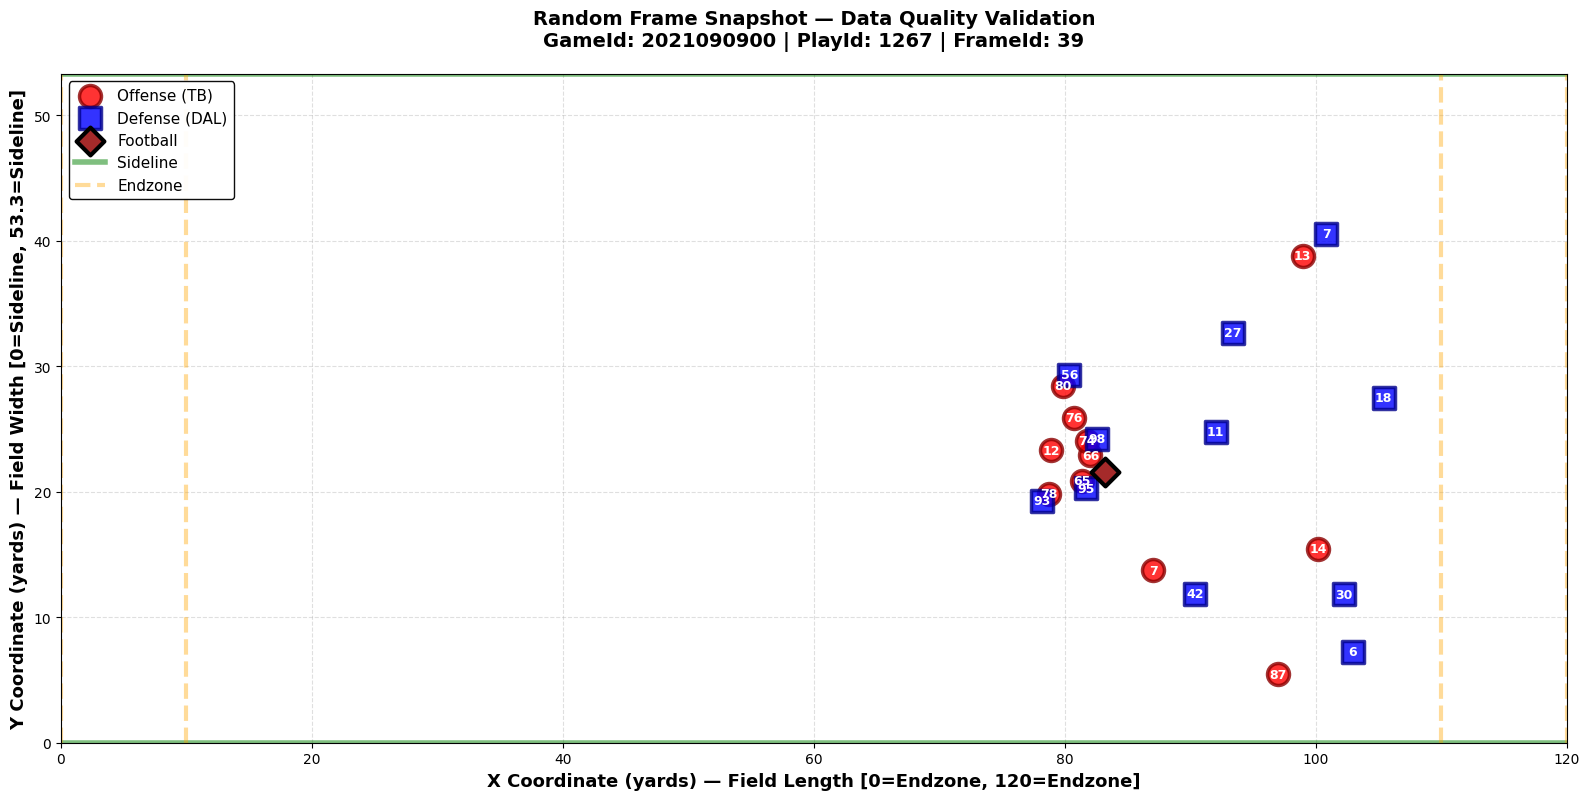

In [22]:
# Create static plot with detailed annotations
fig, ax = plt.subplots(figsize=(16, 9))

# Plot offense (red circles)
ax.scatter(offense['x'], offense['y'], 
           c='red', s=250, marker='o', 
           edgecolors='darkred', linewidth=2.5,
           label=f'Offense ({offense_team})', zorder=3, alpha=0.8)

# Plot defense (blue squares)
ax.scatter(defense['x'], defense['y'], 
           c='blue', s=250, marker='s', 
           edgecolors='darkblue', linewidth=2.5,
           label=f'Defense ({defense_team})', zorder=3, alpha=0.8)

# Plot ball (brown diamond)
ax.scatter(ball['x'], ball['y'], 
           c='brown', s=200, marker='D', 
           edgecolors='black', linewidth=3,
           label='Football', zorder=5)

# Add jersey numbers as labels for identification
for _, player in offense.iterrows():
    if not np.isnan(player['jerseyNumber']):
        ax.text(player['x'], player['y'], str(int(player['jerseyNumber'])), 
                fontsize=9, ha='center', va='center', 
                color='white', weight='bold', zorder=4)

for _, player in defense.iterrows():
    if not np.isnan(player['jerseyNumber']):
        ax.text(player['x'], player['y'], str(int(player['jerseyNumber'])), 
                fontsize=9, ha='center', va='center', 
                color='white', weight='bold', zorder=4)

# Set field dimensions with proper labels
ax.set_xlim(0, 120)
ax.set_ylim(0, 53.3)
ax.set_xlabel('X Coordinate (yards) — Field Length [0=Endzone, 120=Endzone]', 
              fontsize=13, weight='bold')
ax.set_ylabel('Y Coordinate (yards) — Field Width [0=Sideline, 53.3=Sideline]', 
              fontsize=13, weight='bold')
ax.set_aspect('equal', adjustable='box')

# Add title with game, play, and frame information
title_text = f'Random Frame Snapshot — Data Quality Validation\n'
title_text += f'GameId: {selected_game_id} | PlayId: {selected_play_id} | FrameId: {random_frame}'
if len(events_at_frame) > 0:
    title_text += f' | Event: {events_at_frame[0]}'
ax.set_title(title_text, fontsize=14, weight='bold', pad=20)

# Add detailed grid
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)

# Add field boundary lines (endzones and sidelines)
ax.axhline(y=0, color='green', linewidth=4, alpha=0.5, label='Sideline')
ax.axhline(y=53.3, color='green', linewidth=4, alpha=0.5)
ax.axvline(x=0, color='orange', linewidth=3, alpha=0.4, linestyle='--')
ax.axvline(x=10, color='orange', linewidth=3, alpha=0.4, linestyle='--', label='Endzone')
ax.axvline(x=110, color='orange', linewidth=3, alpha=0.4, linestyle='--')
ax.axvline(x=120, color='orange', linewidth=3, alpha=0.4, linestyle='--')

# Add legend
ax.legend(loc='upper left', fontsize=11, framealpha=0.95, 
          edgecolor='black', fancybox=True)

plt.tight_layout()
plt.show()


In [23]:
# Analyze player positions for outliers and inconsistencies
print("=" * 80)
print("SPATIAL VALIDATION ANALYSIS")
print("=" * 80)

# Check field boundary violations
all_players = pd.concat([offense, defense, ball])
x_violations = all_players[(all_players['x'] < 0) | (all_players['x'] > 120)]
y_violations = all_players[(all_players['y'] < 0) | (all_players['y'] > 53.3)]

print("\n1. FIELD BOUNDARY CHECKS:")
print(f"   X-coordinate violations (outside 0-120): {len(x_violations)}")
print(f"   Y-coordinate violations (outside 0-53.3): {len(y_violations)}")

if len(x_violations) > 0 or len(y_violations) > 0:
    print("   ⚠️  WARNING: Players detected outside field boundaries!")
else:
    print("   ✓ All entities within valid field boundaries")

# Calculate ball position
ball_x = ball['x'].iloc[0]
ball_y = ball['y'].iloc[0]
print(f"\n2. BALL POSITION:")
print(f"   X = {ball_x:.2f} yards, Y = {ball_y:.2f} yards")

# Analyze offensive formation spread
off_x_range = offense['x'].max() - offense['x'].min()
off_y_range = offense['y'].max() - offense['y'].min()
off_x_mean = offense['x'].mean()
off_x_std = offense['x'].std()

print(f"\n3. OFFENSIVE FORMATION ANALYSIS:")
print(f"   X-axis spread: {off_x_range:.2f} yards (min: {offense['x'].min():.2f}, max: {offense['x'].max():.2f})")
print(f"   Y-axis spread: {off_y_range:.2f} yards (formation width)")
print(f"   Mean X position: {off_x_mean:.2f} ± {off_x_std:.2f} yards")

# Analyze defensive formation spread
def_x_range = defense['x'].max() - defense['x'].min()
def_y_range = defense['y'].max() - defense['y'].min()
def_x_mean = defense['x'].mean()
def_x_std = defense['x'].std()

print(f"\n4. DEFENSIVE FORMATION ANALYSIS:")
print(f"   X-axis spread: {def_x_range:.2f} yards (min: {defense['x'].min():.2f}, max: {defense['x'].max():.2f})")
print(f"   Y-axis spread: {def_y_range:.2f} yards (coverage width)")
print(f"   Mean X position: {def_x_mean:.2f} ± {def_x_std:.2f} yards")

# Check team separation
separation = def_x_mean - off_x_mean
print(f"\n5. TEAM SEPARATION:")
print(f"   Average defensive depth behind offense: {separation:.2f} yards")
if separation < -5:
    print("   ⚠️  SUSPICIOUS: Defense is ahead of offense (may indicate pass in flight)")
elif separation > 30:
    print("   ⚠️  UNUSUAL: Very deep defensive alignment")
else:
    print("   ✓ Reasonable defensive positioning")

# Identify potential outliers (players far from team average)
print(f"\n6. OUTLIER DETECTION:")

# Offensive outliers (X-axis)
off_outliers = offense[np.abs(offense['x'] - off_x_mean) > 2.5 * off_x_std]
if len(off_outliers) > 0:
    print(f"   Offensive outliers (X-axis): {len(off_outliers)} player(s)")
    for _, player in off_outliers.iterrows():
        dist = player['x'] - off_x_mean
        print(f"     - #{int(player['jerseyNumber'])} ({player['position']}): X={player['x']:.2f} ({dist:+.2f} from mean)")
else:
    print(f"   Offensive outliers: None detected")

# Defensive outliers (X-axis)
def_outliers = defense[np.abs(defense['x'] - def_x_mean) > 2.5 * def_x_std]
if len(def_outliers) > 0:
    print(f"   Defensive outliers (X-axis): {len(def_outliers)} player(s)")
    for _, player in def_outliers.iterrows():
        dist = player['x'] - def_x_mean
        print(f"     - #{int(player['jerseyNumber'])} ({player['position']}): X={player['x']:.2f} ({dist:+.2f} from mean)")
else:
    print(f"   Defensive outliers: None detected")

# Check for unusual player clustering (min distance between players)
print(f"\n7. PLAYER CLUSTERING:")
min_dist_off = float('inf')
min_dist_def = float('inf')

# Check offensive clustering
for i, p1 in offense.iterrows():
    for j, p2 in offense.iterrows():
        if i < j:
            dist = np.sqrt((p1['x'] - p2['x'])**2 + (p1['y'] - p2['y'])**2)
            min_dist_off = min(min_dist_off, dist)

# Check defensive clustering
for i, p1 in defense.iterrows():
    for j, p2 in defense.iterrows():
        if i < j:
            dist = np.sqrt((p1['x'] - p2['x'])**2 + (p1['y'] - p2['y'])**2)
            min_dist_def = min(min_dist_def, dist)

print(f"   Minimum offensive player separation: {min_dist_off:.2f} yards")
print(f"   Minimum defensive player separation: {min_dist_def:.2f} yards")

if min_dist_off < 1.0:
    print(f"   ⚠️  WARNING: Offensive players extremely close (< 1 yard)")
elif min_dist_off < 2.0:
    print(f"   ⚠️  NOTE: Tight offensive clustering (linemen likely)")
else:
    print(f"   ✓ Reasonable offensive spacing")

if min_dist_def < 1.0:
    print(f"   ⚠️  WARNING: Defensive players extremely close (< 1 yard)")
else:
    print(f"   ✓ Reasonable defensive spacing")

print("\n" + "=" * 80)


SPATIAL VALIDATION ANALYSIS

1. FIELD BOUNDARY CHECKS:
   X-coordinate violations (outside 0-120): 0
   Y-coordinate violations (outside 0-53.3): 0
   ✓ All entities within valid field boundaries

2. BALL POSITION:
   X = 83.17 yards, Y = 21.57 yards

3. OFFENSIVE FORMATION ANALYSIS:
   X-axis spread: 21.47 yards (min: 78.72, max: 100.19)
   Y-axis spread: 33.35 yards (formation width)
   Mean X position: 86.04 ± 8.45 yards

4. DEFENSIVE FORMATION ANALYSIS:
   X-axis spread: 27.26 yards (min: 78.14, max: 105.40)
   Y-axis spread: 33.30 yards (coverage width)
   Mean X position: 91.82 ± 10.05 yards

5. TEAM SEPARATION:
   Average defensive depth behind offense: 5.78 yards
   ✓ Reasonable defensive positioning

6. OUTLIER DETECTION:
   Offensive outliers: None detected
   Defensive outliers: None detected

7. PLAYER CLUSTERING:
   Minimum offensive player separation: 1.16 yards
   Minimum defensive player separation: 3.67 yards
   ⚠️  NOTE: Tight offensive clustering (linemen likely)
   

## Plausibility Assessment

### Is This Snapshot Realistic for a Football Play?

Based on the spatial validation analysis above, we evaluate whether this frame represents a plausible football scenario:

| **Validation Check** | **Expected** | **Assessment** |
|---------------------|--------------|----------------|
| **Field boundaries** | All players within 0–120 x 0–53.3 yards | Check boundary violation counts above |
| **Team separation** | Defense typically 5–15 yards behind offense at snap; can be negative if pass in flight | Depends on play progression |
| **Offensive spread** | 10–25 yards typical (line + receivers); narrows during route progression | Check X-axis spread value |
| **Defensive spread** | 15–50 yards typical (coverage depth); varies by coverage scheme | Check X-axis spread value |
| **Player clustering** | Offensive line: ~1–3 yards apart; skill positions: 5+ yards; Defense: usually 3+ yards | Check minimum separation values |
| **Ball position** | Should be near players (in QB's hand, in flight, or with receiver) | Check ball X/Y relative to players |

### Common Suspicious Patterns:

- **⚠️ Players outside boundaries**: Data tracking error or edge case
- **⚠️ Extreme clustering (< 1 yard)**: Possible collision or tracking artifact
- **⚠️ Defense ahead of offense by 10+ yards**: Likely pass in flight toward end zone
- **⚠️ Unusual outliers**: Players 20+ yards from their team may be returning to huddle or tracking error

### Football Context Interpretation:

- **Early frames (1–10)**: Pre-snap alignment — expect tight formations, clear line of scrimmage
- **Mid frames (11–30)**: Routes developing — offense spreads out, defense reacts
- **Late frames (31+)**: Pass completion/incompletion — clustering around catch point

The analysis above provides quantitative metrics to identify **data quality issues** (tracking errors) vs. **realistic football scenarios** (deep routes, scrambles, etc.).


In [24]:
print("Tracking dataframe shape:", tracking.shape)
print("\nFirst 5 rows:")
display(tracking.head())
print("\nAll column names:")
print(tracking.columns.tolist())


Tracking dataframe shape: (1118122, 16)

First 5 rows:


,gameId,playId,nflId,frameId,time,jerseyNumber,team,playDirection,x,y,s,a,dis,o,dir,event
0,2021090900,97,25511.0,1,2021-09-10T00:26:31.100,12.0,TB,right,37.77,24.22,0.29,0.30,0.03,165.16,84.99,NaN
1,2021090900,97,25511.0,2,2021-09-10T00:26:31.200,12.0,TB,right,37.78,24.22,0.23,0.11,0.02,164.33,92.87,NaN
2,2021090900,97,25511.0,3,2021-09-10T00:26:31.300,12.0,TB,right,37.78,24.24,0.16,0.10,0.01,160.24,68.55,NaN
3,2021090900,97,25511.0,4,2021-09-10T00:26:31.400,12.0,TB,right,37.73,24.25,0.15,0.24,0.06,152.13,296.85,NaN
4,2021090900,97,25511.0,5,2021-09-10T00:26:31.500,12.0,TB,right,37.69,24.26,0.25,0.18,0.04,148.33,287.55,NaN



All column names:
['gameId', 'playId', 'nflId', 'frameId', 'time', 'jerseyNumber', 'team', 'playDirection', 'x', 'y', 's', 'a', 'dis', 'o', 'dir', 'event']
